<a href="https://colab.research.google.com/github/RiccardoD25/CPP-Programs/blob/main/CST620_Week01_Kaggle_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01 — Classical Pipeline to CNN/ViT Architecture Selector

**Colab-ready replacement notebook — Kaggle edition**

- **Public dataset:** Kaggle Malaria Cell Images
- **Compared families:** OpenCV/HOG + Linear SVM, small CNN, and DeiT-tiny Vision Transformer
- **Measured outputs:** Held-out accuracy, total model parameters, and end-to-end CPU inference latency
- **Decision context:** Limited labeled data and a lightweight CPU/edge deployment target

This notebook intentionally avoids `tensorflow_datasets`. KaggleHub downloads the public dataset directly from Kaggle.

> This is an academic architecture-selection prototype, not a clinically validated diagnostic system.

## Before running

1. Open this notebook in Google Colab.
2. Select **Runtime → Change runtime type → T4 GPU** if available.
3. Select **Runtime → Run all**.
4. Allow the first cell to install the required packages.
5. The first Kaggle download may take several minutes.
6. Do not manually enter metric values; the final table is produced from actual model outputs.

`FAST_MODE = True` uses 500 images and short training for the recorded demonstration. Set it to `False` only if you want a larger final experiment and have additional time.

In [22]:
# Run this first. TensorFlow and tensorflow_datasets are intentionally not used.
%pip install -q kagglehub==1.0.2 opencv-python-headless timm scikit-learn pandas matplotlib tqdm

In [23]:
import copy
import os
import random
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
FAST_MODE = True

SAMPLES_PER_CLASS = 250 if FAST_MODE else 600
CNN_EPOCHS = 3 if FAST_MODE else 7
VIT_EPOCHS = 2 if FAST_MODE else 4
BATCH_SIZE = 32
IMAGE_SIZE = 224

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("KaggleHub version:", getattr(kagglehub, "__version__", "available"))
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)
print("Mode:", "FAST demonstration" if FAST_MODE else "LARGER final experiment")
print("Requested images:", 2 * SAMPLES_PER_CLASS)

KaggleHub version: 1.0.2
PyTorch version: 2.11.0+cu128
Device: cuda
Mode: FAST demonstration
Requested images: 500


## 1. Download the public Kaggle medical-image dataset

The Kaggle dataset contains parasitized and uninfected cell images. KaggleHub normally downloads this public resource without credentials. The returned folder is searched programmatically, so the notebook does not depend on one fixed Colab path.

In [24]:
DATASET_HANDLE = "iarunava/cell-images-for-detecting-malaria"

dataset_path = Path(kagglehub.dataset_download(DATASET_HANDLE))
print("Dataset downloaded to:", dataset_path)

Using Colab cache for faster access to the 'cell-images-for-detecting-malaria' dataset.
Dataset downloaded to: /kaggle/input/cell-images-for-detecting-malaria


In [25]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}
CLASS_SPECS = [
    ("Parasitized", {"parasitized", "infected"}),
    ("Uninfected", {"uninfected"}),
]

def direct_image_files(directory):
    return sorted(
        path
        for path in directory.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

def find_best_label_directory(root, accepted_names):
    candidates = []
    for directory in root.rglob("*"):
        if directory.is_dir() and directory.name.lower() in accepted_names:
            files = direct_image_files(directory)
            if files:
                candidates.append((len(files), directory, files))

    if not candidates:
        raise FileNotFoundError(
            f"No image directory matching {sorted(accepted_names)} was found under {root}"
        )

    # Select the matching folder containing the most direct image files.
    candidates.sort(key=lambda item: item[0], reverse=True)
    return candidates[0][1], candidates[0][2]

rng = random.Random(SEED)
selected_paths = []
selected_labels = []
CLASS_NAMES = []

for class_id, (class_name, accepted_names) in enumerate(CLASS_SPECS):
    label_directory, available_files = find_best_label_directory(
        dataset_path,
        accepted_names,
    )

    if len(available_files) < SAMPLES_PER_CLASS:
        raise RuntimeError(
            f"{class_name} contains only {len(available_files)} usable images, "
            f"but {SAMPLES_PER_CLASS} were requested."
        )

    rng.shuffle(available_files)
    chosen_files = available_files[:SAMPLES_PER_CLASS]

    selected_paths.extend(chosen_files)
    selected_labels.extend([class_id] * len(chosen_files))
    CLASS_NAMES.append(class_name)

    print(
        f"{class_name}: selected {len(chosen_files)} of "
        f"{len(available_files)} images from {label_directory}"
    )

image_paths = np.asarray(selected_paths, dtype=object)
labels = np.asarray(selected_labels, dtype=np.int64)

print("Total selected images:", len(image_paths))
display(
    pd.Series(labels)
    .map(dict(enumerate(CLASS_NAMES)))
    .value_counts()
    .rename("count")
)

Parasitized: selected 250 of 13779 images from /kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized
Uninfected: selected 250 of 13779 images from /kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected
Total selected images: 500


,count
Parasitized,250
Uninfected,250


## 2. Split raw file paths before preprocessing or fitting

A stratified 70%/15%/15% split is created from the raw image paths:

- Fixed OpenCV operations work independently on each image and learn no dataset-wide statistics.
- Random augmentation is applied only to training images.
- The HOG standardizer and SVM are fitted only on training features.
- Validation accuracy selects the best neural-network epoch.
- The test set is reserved for the final metrics.

**Medical-evaluation limitation:** This Kaggle version does not expose patient identifiers in the filenames used here. Patient-level independence therefore cannot be verified. A clinical study must use patient- and site-level splitting.

In [26]:
all_indices = np.arange(len(labels))

train_indices, temporary_indices = train_test_split(
    all_indices,
    test_size=0.30,
    random_state=SEED,
    stratify=labels,
)

validation_indices, test_indices = train_test_split(
    temporary_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=labels[temporary_indices],
)

assert set(train_indices).isdisjoint(validation_indices)
assert set(train_indices).isdisjoint(test_indices)
assert set(validation_indices).isdisjoint(test_indices)

train_paths = image_paths[train_indices]
validation_paths = image_paths[validation_indices]
test_paths = image_paths[test_indices]

y_train = labels[train_indices]
y_validation = labels[validation_indices]
y_test = labels[test_indices]

def describe_split(split_name, targets):
    counts = pd.Series(targets).map(dict(enumerate(CLASS_NAMES))).value_counts()
    return pd.DataFrame({
        "split": split_name,
        "class": counts.index,
        "count": counts.values,
    })

split_table = pd.concat([
    describe_split("train", y_train),
    describe_split("validation", y_validation),
    describe_split("test", y_test),
], ignore_index=True)

display(split_table)
print(
    f"Split sizes — train: {len(train_paths)}, "
    f"validation: {len(validation_paths)}, test: {len(test_paths)}"
)

,split,class,count
0,train,Uninfected,175
1,train,Parasitized,175
2,validation,Uninfected,38
3,validation,Parasitized,37
4,test,Parasitized,38
5,test,Uninfected,37


Split sizes — train: 350, validation: 75, test: 75


## 3. OpenCV preprocessing pipeline

Operation order:

1. Read the Kaggle image with OpenCV, which produces BGR.
2. Convert BGR to RGB for correct display and consistent processing.
3. Resize to 224 × 224 for matched architecture inputs.
4. Convert RGB to grayscale.
5. Apply CLAHE histogram equalization for local contrast.
6. Apply a small Gaussian blur to reduce noise before edge detection.
7. Apply Canny edge detection.
8. Morphologically close small gaps in the edge map.
9. Stack equalized intensity, edges, and closed edges into three model channels.

The settings are fixed in advance and applied independently to every image.

In [27]:
def read_rgb(image_path):
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"OpenCV could not read: {image_path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

def opencv_preprocess(image_rgb, output_size=IMAGE_SIZE, return_stages=False):
    resized_rgb = cv2.resize(
        image_rgb,
        (output_size, output_size),
        interpolation=cv2.INTER_AREA,
    )
    grayscale = cv2.cvtColor(resized_rgb, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8),
    )
    equalized = clahe.apply(grayscale)

    blurred = cv2.GaussianBlur(
        equalized,
        (5, 5),
        sigmaX=0,
    )
    edges = cv2.Canny(
        blurred,
        threshold1=50,
        threshold2=150,
    )

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3),
    )
    closed_edges = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1,
    )

    processed = np.stack(
        [equalized, edges, closed_edges],
        axis=-1,
    ).astype(np.uint8)

    if return_stages:
        return {
            "resized_rgb": resized_rgb,
            "grayscale": grayscale,
            "equalized": equalized,
            "edges": edges,
            "closed_edges": closed_edges,
            "processed": processed,
        }

    return processed

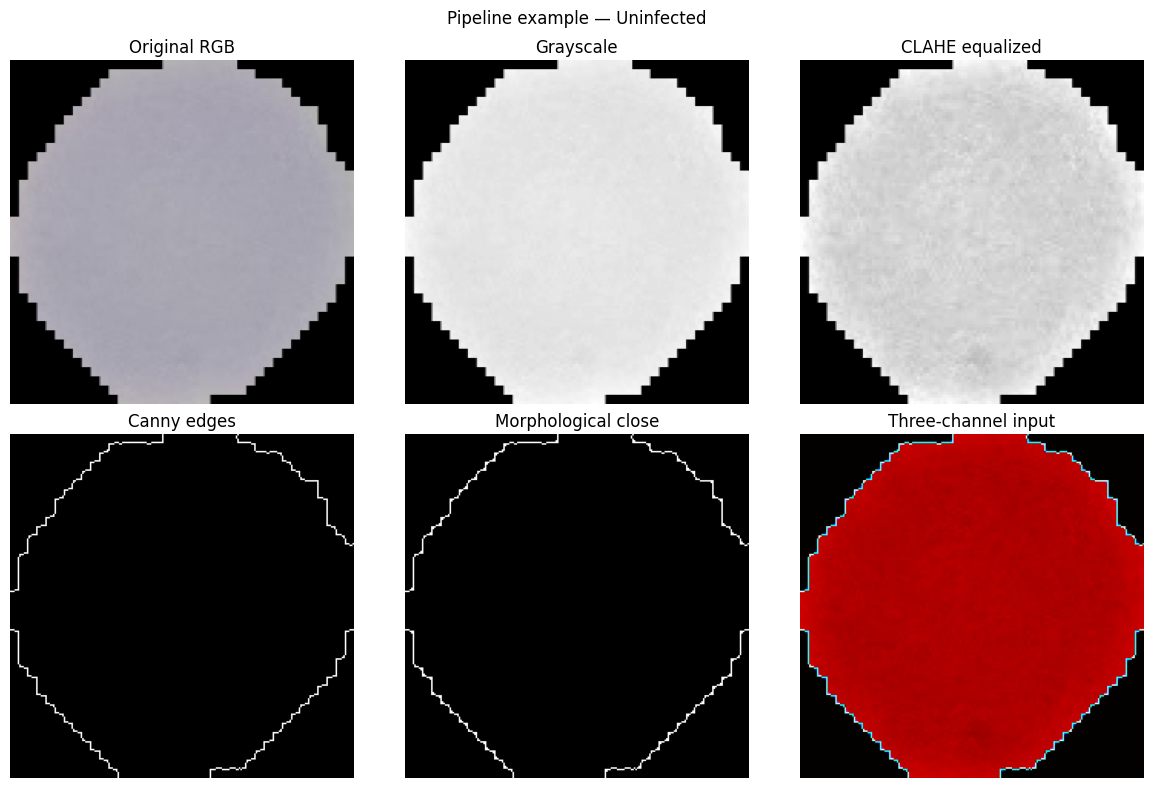

In [28]:
example_rgb = read_rgb(train_paths[0])
example_stages = opencv_preprocess(
    example_rgb,
    return_stages=True,
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
panels = [
    ("Original RGB", example_stages["resized_rgb"], None),
    ("Grayscale", example_stages["grayscale"], "gray"),
    ("CLAHE equalized", example_stages["equalized"], "gray"),
    ("Canny edges", example_stages["edges"], "gray"),
    ("Morphological close", example_stages["closed_edges"], "gray"),
    ("Three-channel input", example_stages["processed"], None),
]

for axis, (title, image, color_map) in zip(axes.ravel(), panels):
    axis.imshow(image, cmap=color_map)
    axis.set_title(title)
    axis.axis("off")

fig.suptitle(f"Pipeline example — {CLASS_NAMES[y_train[0]]}")
plt.tight_layout()
plt.show()

In [29]:
def process_paths(paths, description):
    processed_images = []
    for path in tqdm(paths, desc=description):
        image_rgb = read_rgb(path)
        processed_images.append(opencv_preprocess(image_rgb))
    return np.stack(processed_images)

X_train = process_paths(train_paths, "Preprocessing train")
X_validation = process_paths(validation_paths, "Preprocessing validation")
X_test = process_paths(test_paths, "Preprocessing test")

print("Training array:", X_train.shape)
print("Validation array:", X_validation.shape)
print("Test array:", X_test.shape)

assert X_train.shape[1:] == (IMAGE_SIZE, IMAGE_SIZE, 3)
assert X_validation.shape[1:] == (IMAGE_SIZE, IMAGE_SIZE, 3)
assert X_test.shape[1:] == (IMAGE_SIZE, IMAGE_SIZE, 3)

Preprocessing train:   0%|          | 0/350 [00:00<?, ?it/s]

Preprocessing validation:   0%|          | 0/75 [00:00<?, ?it/s]

Preprocessing test:   0%|          | 0/75 [00:00<?, ?it/s]

Training array: (350, 224, 224, 3)
Validation array: (75, 224, 224, 3)
Test array: (75, 224, 224, 3)


## 4. Classical baseline: OpenCV channels → HOG → Linear SVM

The image-processing pipeline is not treated as a classifier by itself. HOG features are extracted from all three processed channels and passed to a Linear SVM. StandardScaler and the SVM are fitted only on the training features.

In [30]:
%pip install -q scikit-image

from skimage.feature import hog

HOG_SIZE = 64

def extract_hog_one(processed_image):
    feature_parts = []

    for channel_index in range(processed_image.shape[-1]):
        channel = cv2.resize(
            processed_image[:, :, channel_index],
            (HOG_SIZE, HOG_SIZE),
            interpolation=cv2.INTER_AREA,
        )

        features = hog(
            channel,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            feature_vector=True,
        )

        feature_parts.append(features)

    return np.concatenate(feature_parts).astype(np.float32)

def extract_hog_batch(images, description):
    return np.stack([
        extract_hog_one(image)
        for image in tqdm(images, desc=description)
    ])

X_train_hog = extract_hog_batch(X_train, "HOG train")
X_validation_hog = extract_hog_batch(
    X_validation,
    "HOG validation",
)
X_test_hog = extract_hog_batch(X_test, "HOG test")

classical_model = make_pipeline(
    StandardScaler(),
    LinearSVC(
        C=1.0,
        max_iter=5000,
        random_state=SEED,
        dual=True,
    ),
)

classical_model.fit(X_train_hog, y_train)

classical_validation_predictions = classical_model.predict(
    X_validation_hog
)
classical_test_predictions = classical_model.predict(
    X_test_hog
)

classical_validation_accuracy = accuracy_score(
    y_validation,
    classical_validation_predictions,
)

classical_test_accuracy = accuracy_score(
    y_test,
    classical_test_predictions,
)

svm_model = classical_model.named_steps["linearsvc"]

classical_parameter_count = int(
    svm_model.coef_.size + svm_model.intercept_.size
)

print(
    f"Classical validation accuracy: "
    f"{classical_validation_accuracy:.3f}"
)
print(
    f"Classical test accuracy: "
    f"{classical_test_accuracy:.3f}"
)
print(
    f"SVM coefficients/intercepts: "
    f"{classical_parameter_count:,}"
)

HOG train:   0%|          | 0/350 [00:00<?, ?it/s]

HOG validation:   0%|          | 0/75 [00:00<?, ?it/s]

HOG test:   0%|          | 0/75 [00:00<?, ?it/s]

Classical validation accuracy: 0.787
Classical test accuracy: 0.787
SVM coefficients/intercepts: 5,293


## 5. Matched PyTorch inputs

Both neural architectures receive the same processed 224 × 224 three-channel arrays and the same normalization. Random flips and rotation are restricted to training. Cell orientation does not define the malaria label, but augmentation assumptions would require domain review for retinal anatomy.

In [31]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

training_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.25),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

evaluation_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ProcessedImageDataset(Dataset):
    def __init__(self, images, targets, transform):
        self.images = images
        self.targets = torch.as_tensor(
            targets,
            dtype=torch.long,
        )
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, index):
        image_tensor = self.transform(self.images[index])
        return image_tensor, self.targets[index]

train_dataset = ProcessedImageDataset(
    X_train,
    y_train,
    training_transform,
)
validation_dataset = ProcessedImageDataset(
    X_validation,
    y_validation,
    evaluation_transform,
)
test_dataset = ProcessedImageDataset(
    X_test,
    y_test,
    evaluation_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

sample_batch, sample_targets = next(iter(train_loader))
print("Model input shape:", tuple(sample_batch.shape))
print("Target shape:", tuple(sample_targets.shape))

assert sample_batch.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)

Model input shape: (32, 3, 224, 224)
Target shape: (32,)


## 6. Small CNN and tiny Vision Transformer

- The CNN has three convolutional stages and is trained from scratch.
- DeiT-tiny uses pretrained weights when available. With limited data, only its final transformer block, normalization, and classification head are fine-tuned.
- If pretrained weights cannot be downloaded, the notebook clearly reports the fallback and trains the full ViT from random initialization.

In [32]:
class SmallCNN(nn.Module):
    def __init__(self, number_of_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p=0.25),
            nn.Linear(128, number_of_classes),
        )

    def forward(self, inputs):
        return self.classifier(self.features(inputs))

def build_tiny_vit(number_of_classes):
    try:
        model = timm.create_model(
            "deit_tiny_patch16_224",
            pretrained=True,
            num_classes=number_of_classes,
        )
        pretrained_loaded = True
    except Exception as error:
        print("Pretrained ViT weights were unavailable.")
        print("Using random initialization:", str(error)[:200])

        model = timm.create_model(
            "deit_tiny_patch16_224",
            pretrained=False,
            num_classes=number_of_classes,
        )
        pretrained_loaded = False

    if pretrained_loaded:
        for parameter in model.parameters():
            parameter.requires_grad = False

        for parameter in model.blocks[-1].parameters():
            parameter.requires_grad = True

        for parameter in model.norm.parameters():
            parameter.requires_grad = True

        for parameter in model.head.parameters():
            parameter.requires_grad = True

    return model, pretrained_loaded

def count_parameters(model):
    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )
    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    return int(total_parameters), int(trainable_parameters)

cnn_model = SmallCNN(len(CLASS_NAMES)).to(DEVICE)
vit_model, VIT_PRETRAINED = build_tiny_vit(len(CLASS_NAMES))
vit_model = vit_model.to(DEVICE)

print("CNN parameters:", count_parameters(cnn_model))
print("ViT parameters:", count_parameters(vit_model))
print("ViT pretrained:", VIT_PRETRAINED)

CNN parameters: (93954, 93954)
ViT parameters: (5524802, 445634)
ViT pretrained: True


In [33]:
# Verify both architectures before starting longer training loops.
smoke_inputs = sample_batch[:2].to(DEVICE)

cnn_model.eval()
vit_model.eval()

with torch.inference_mode():
    cnn_logits = cnn_model(smoke_inputs)
    vit_logits = vit_model(smoke_inputs)

print("CNN output shape:", tuple(cnn_logits.shape))
print("ViT output shape:", tuple(vit_logits.shape))

assert cnn_logits.shape == (2, len(CLASS_NAMES))
assert vit_logits.shape == (2, len(CLASS_NAMES))

CNN output shape: (2, 2)
ViT output shape: (2, 2)


## 7. Train with validation checkpointing

The best model state is selected using validation accuracy. The held-out test set does not influence training or checkpoint selection.

In [34]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    correct = 0
    sample_count = 0

    for inputs, targets in loader:
        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(inputs)
            loss = criterion(logits, targets)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * targets.size(0)
        correct += (
            logits.argmax(dim=1) == targets
        ).sum().item()
        sample_count += targets.size(0)

    return (
        total_loss / sample_count,
        correct / sample_count,
    )

def train_with_validation(
    model,
    train_data,
    validation_data,
    epochs,
    learning_rate,
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        [
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ],
        lr=learning_rate,
        weight_decay=1e-4,
    )

    history = []
    best_validation_accuracy = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(
            model,
            train_data,
            criterion,
            optimizer,
        )

        validation_loss, validation_accuracy = run_epoch(
            model,
            validation_data,
            criterion,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
        })

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} | "
            f"train accuracy {train_accuracy:.3f} | "
            f"validation accuracy {validation_accuracy:.3f}"
        )

    model.load_state_dict(best_state)
    return pd.DataFrame(history)

@torch.inference_mode()
def evaluate_neural_model(model, loader):
    model.eval()

    predictions = []
    targets_all = []

    for inputs, targets in loader:
        logits = model(inputs.to(DEVICE))
        predictions.extend(
            logits.argmax(dim=1).cpu().numpy()
        )
        targets_all.extend(targets.numpy())

    predictions = np.asarray(predictions)
    targets_all = np.asarray(targets_all)

    return (
        accuracy_score(targets_all, predictions),
        predictions,
    )

In [35]:
print("Training the small CNN")

cnn_history = train_with_validation(
    cnn_model,
    train_loader,
    validation_loader,
    epochs=CNN_EPOCHS,
    learning_rate=1e-3,
)

Training the small CNN
Epoch 01/3 | train loss 0.6240 | train accuracy 0.654 | validation accuracy 0.520
Epoch 02/3 | train loss 0.5699 | train accuracy 0.743 | validation accuracy 0.520
Epoch 03/3 | train loss 0.5426 | train accuracy 0.797 | validation accuracy 0.653


In [36]:
print("Training the DeiT-tiny ViT")

vit_learning_rate = 1e-4 if VIT_PRETRAINED else 3e-4

vit_history = train_with_validation(
    vit_model,
    train_loader,
    validation_loader,
    epochs=VIT_EPOCHS,
    learning_rate=vit_learning_rate,
)

Training the DeiT-tiny ViT
Epoch 01/2 | train loss 0.6845 | train accuracy 0.614 | validation accuracy 0.853
Epoch 02/2 | train loss 0.5170 | train accuracy 0.817 | validation accuracy 0.813


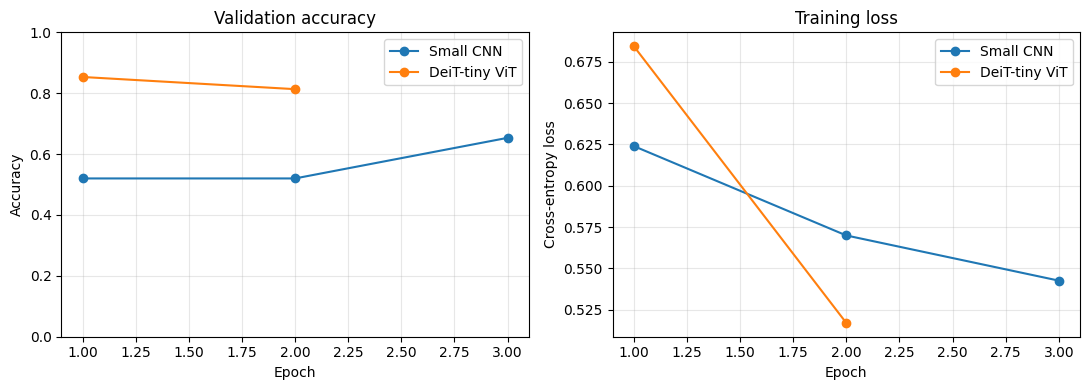

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    cnn_history["epoch"],
    cnn_history["validation_accuracy"],
    marker="o",
    label="Small CNN",
)
axes[0].plot(
    vit_history["epoch"],
    vit_history["validation_accuracy"],
    marker="o",
    label="DeiT-tiny ViT",
)
axes[0].set_title("Validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    cnn_history["epoch"],
    cnn_history["train_loss"],
    marker="o",
    label="Small CNN",
)
axes[1].plot(
    vit_history["epoch"],
    vit_history["train_loss"],
    marker="o",
    label="DeiT-tiny ViT",
)
axes[1].set_title("Training loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross-entropy loss")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Final test accuracy and end-to-end CPU latency

Latency uses a raw image already held in memory, batch size 1, CPU execution, and warm-up runs. Every timing includes the same OpenCV preprocessing. Classical timing then includes HOG and SVM prediction; neural timing includes tensor conversion and model prediction.

In [38]:
def benchmark_classical_cpu(
    raw_rgb,
    model,
    warmup=5,
    runs=30,
):
    def one_inference():
        processed = opencv_preprocess(raw_rgb)
        features = extract_hog_one(processed).reshape(1, -1)
        model.predict(features)

    for _ in range(warmup):
        one_inference()

    durations_ms = []
    for _ in range(runs):
        start = time.perf_counter()
        one_inference()
        durations_ms.append(
            (time.perf_counter() - start) * 1000
        )

    return float(np.mean(durations_ms))

def benchmark_torch_cpu(
    model,
    raw_rgb,
    warmup=5,
    runs=30,
):
    cpu_model = copy.deepcopy(model).to("cpu").eval()
    torch.set_num_threads(
        max(1, min(4, os.cpu_count() or 1))
    )

    def one_inference():
        processed = opencv_preprocess(raw_rgb)
        tensor = evaluation_transform(processed)
        tensor = tensor.unsqueeze(0)

        with torch.inference_mode():
            cpu_model(tensor)

    for _ in range(warmup):
        one_inference()

    durations_ms = []
    for _ in range(runs):
        start = time.perf_counter()
        one_inference()
        durations_ms.append(
            (time.perf_counter() - start) * 1000
        )

    del cpu_model
    return float(np.mean(durations_ms))

cnn_test_accuracy, cnn_test_predictions = evaluate_neural_model(
    cnn_model,
    test_loader,
)

vit_test_accuracy, vit_test_predictions = evaluate_neural_model(
    vit_model,
    test_loader,
)

raw_benchmark_image = read_rgb(test_paths[0])

classical_latency_ms = benchmark_classical_cpu(
    raw_benchmark_image,
    classical_model,
)
cnn_latency_ms = benchmark_torch_cpu(
    cnn_model,
    raw_benchmark_image,
)
vit_latency_ms = benchmark_torch_cpu(
    vit_model,
    raw_benchmark_image,
)

cnn_total_parameters, cnn_trainable_parameters = count_parameters(
    cnn_model
)
vit_total_parameters, vit_trainable_parameters = count_parameters(
    vit_model
)

print(f"Classical test accuracy: {classical_test_accuracy:.3f}")
print(f"CNN test accuracy: {cnn_test_accuracy:.3f}")
print(f"ViT test accuracy: {vit_test_accuracy:.3f}")

Classical test accuracy: 0.787
CNN test accuracy: 0.613
ViT test accuracy: 0.773


In [39]:
results = pd.DataFrame([
    {
        "Architecture family": "Classical",
        "Model": "OpenCV/HOG + Linear SVM",
        "Test accuracy": classical_test_accuracy,
        "Total parameters": classical_parameter_count,
        "Trainable parameters": classical_parameter_count,
        "CPU latency (ms/image)": classical_latency_ms,
    },
    {
        "Architecture family": "CNN",
        "Model": "Small three-stage CNN",
        "Test accuracy": cnn_test_accuracy,
        "Total parameters": cnn_total_parameters,
        "Trainable parameters": cnn_trainable_parameters,
        "CPU latency (ms/image)": cnn_latency_ms,
    },
    {
        "Architecture family": "Vision Transformer",
        "Model": (
            "DeiT-tiny (transfer learning)"
            if VIT_PRETRAINED
            else "DeiT-tiny (random-init fallback)"
        ),
        "Test accuracy": vit_test_accuracy,
        "Total parameters": vit_total_parameters,
        "Trainable parameters": vit_trainable_parameters,
        "CPU latency (ms/image)": vit_latency_ms,
    },
])

display(
    results.style
    .format({
        "Test accuracy": "{:.1%}",
        "Total parameters": "{:,.0f}",
        "Trainable parameters": "{:,.0f}",
        "CPU latency (ms/image)": "{:.2f}",
    })
    .highlight_max(
        subset=["Test accuracy"],
        color="#c6efce",
    )
    .highlight_min(
        subset=[
            "Total parameters",
            "CPU latency (ms/image)",
        ],
        color="#c6efce",
    )
)

results.to_csv(
    OUTPUT_DIR / "architecture_comparison.csv",
    index=False,
)

print("Saved:", OUTPUT_DIR / "architecture_comparison.csv")
print(
    "Note: the classical count represents SVM coefficients/intercepts; "
    "it is a useful complexity proxy but is not perfectly equivalent "
    "to a neural-network parameter count."
)

,Architecture family,Model,Test accuracy,Total parameters,Trainable parameters,CPU latency (ms/image)
0,Classical,OpenCV/HOG + Linear SVM,78.7%,"5,293","5,293",6.47
1,CNN,Small three-stage CNN,61.3%,"93,954","93,954",27.82
2,Vision Transformer,DeiT-tiny (transfer learning),77.3%,"5,524,802","445,634",41.57


Saved: outputs/architecture_comparison.csv
Note: the classical count represents SVM coefficients/intercepts; it is a useful complexity proxy but is not perfectly equivalent to a neural-network parameter count.


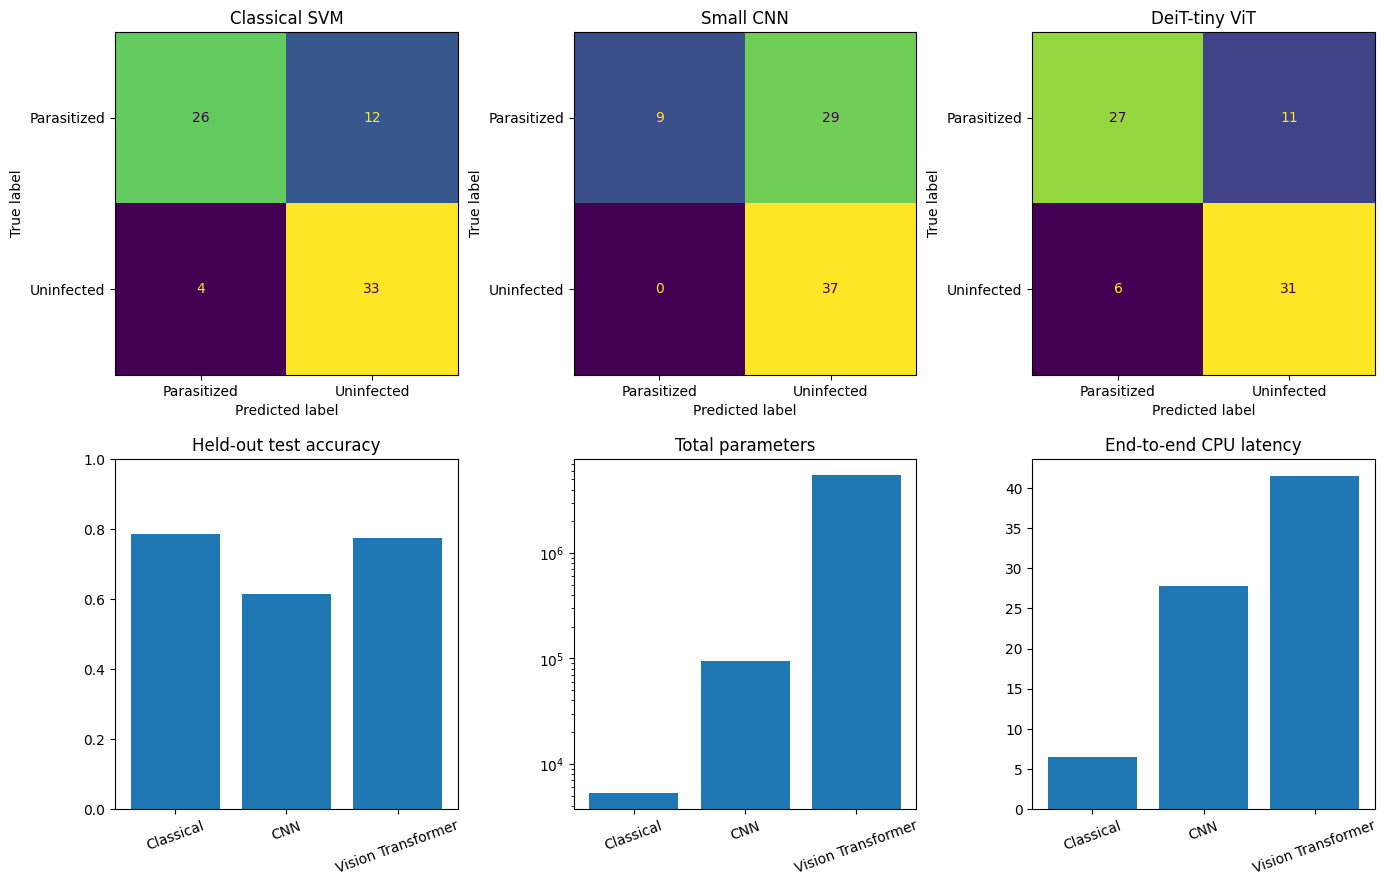

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

prediction_sets = [
    ("Classical SVM", classical_test_predictions),
    ("Small CNN", cnn_test_predictions),
    ("DeiT-tiny ViT", vit_test_predictions),
]

for axis, (model_name, predictions) in zip(
    axes[0],
    prediction_sets,
):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=CLASS_NAMES,
        colorbar=False,
        ax=axis,
    )
    axis.set_title(model_name)

axes[1, 0].bar(
    results["Architecture family"],
    results["Test accuracy"],
)
axes[1, 0].set_title("Held-out test accuracy")
axes[1, 0].set_ylim(0, 1)

axes[1, 1].bar(
    results["Architecture family"],
    results["Total parameters"],
)
axes[1, 1].set_title("Total parameters")
axes[1, 1].set_yscale("log")

axes[1, 2].bar(
    results["Architecture family"],
    results["CPU latency (ms/image)"],
)
axes[1, 2].set_title("End-to-end CPU latency")

for axis in axes[1]:
    axis.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 9. Architecture selector

The decision thresholds are explicit:

- Prefer the classical model if it is within 2 percentage points of the best accuracy and is fastest.
- Otherwise prefer the CNN if it is within 3 percentage points of the best accuracy and is both smaller and faster than the ViT.
- Otherwise select the most accurate measured family.

These thresholds represent prototype product constraints, not universal clinical acceptance criteria.

In [41]:
def recommend_architecture(results_frame):
    table = results_frame.set_index("Architecture family")
    best_accuracy = table["Test accuracy"].max()

    classical = table.loc["Classical"]
    cnn = table.loc["CNN"]
    vit = table.loc["Vision Transformer"]

    classical_is_fastest = (
        classical["CPU latency (ms/image)"]
        == table["CPU latency (ms/image)"].min()
    )

    if (
        classical["Test accuracy"] >= best_accuracy - 0.02
        and classical_is_fastest
    ):
        selected_family = "Classical"
        reason = (
            "It is within two percentage points of the best measured "
            "accuracy and has the lowest end-to-end CPU latency."
        )

    elif (
        cnn["Test accuracy"] >= best_accuracy - 0.03
        and cnn["Total parameters"] < vit["Total parameters"]
        and cnn["CPU latency (ms/image)"]
        < vit["CPU latency (ms/image)"]
    ):
        selected_family = "CNN"
        reason = (
            "It is within three percentage points of the best measured "
            "accuracy while remaining smaller and faster than the ViT."
        )

    else:
        selected_family = table["Test accuracy"].idxmax()
        reason = (
            "Its measured accuracy advantage exceeded the lightweight "
            "deployment tolerance used by this prototype."
        )

    selected = table.loc[selected_family]

    recommendation_text = (
        f"Recommended family: {selected_family}. {reason}\n\n"
        f"Measured evidence: {selected['Test accuracy']:.1%} test accuracy, "
        f"{int(selected['Total parameters']):,} parameters, and "
        f"{selected['CPU latency (ms/image)']:.2f} ms/image end-to-end "
        f"CPU latency. The experiment used {len(y_train)} training, "
        f"{len(y_validation)} validation, and {len(y_test)} test images. "
        "For the startup prototype, labeled data are limited and CPU/edge "
        "deployment is preferred. Before clinical use, repeat the analysis "
        "with retinal images, patient- and site-level splitting, external "
        "validation, sensitivity, specificity, ROC-AUC, calibration, "
        "subgroup analysis, and documented risk controls."
    )

    return selected_family, recommendation_text

SELECTED_FAMILY, RECOMMENDATION = recommend_architecture(results)
print(RECOMMENDATION)

with open(
    OUTPUT_DIR / "architecture_recommendation.txt",
    "w",
    encoding="utf-8",
) as recommendation_file:
    recommendation_file.write(RECOMMENDATION)

Recommended family: Classical. It is within two percentage points of the best measured accuracy and has the lowest end-to-end CPU latency.

Measured evidence: 78.7% test accuracy, 5,293 parameters, and 6.47 ms/image end-to-end CPU latency. The experiment used 350 training, 75 validation, and 75 test images. For the startup prototype, labeled data are limited and CPU/edge deployment is preferred. Before clinical use, repeat the analysis with retinal images, patient- and site-level splitting, external validation, sensitivity, specificity, ROC-AUC, calibration, subgroup analysis, and documented risk controls.
